In [1]:
import pandas as pd
import numpy as n
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score

# Import hierarchical clustering functions from scipy:
# dendrogram -> to visualize hierarchical cluster tree
# linkage -> to create hierarchical clustering structure
# fcluster -> to extract final cluster labels from the hierarchy
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
df = pd.read_csv("F:\\01. The Data Psychology\\4. New_Machine_Learning\\11. Clustering\\amazon_clustering.xls")
df.shape

(2000, 14)

In [3]:
df.head()

,Unnamed: 0,product_id,product_name,category,price,discount_pct,final_price,rating,num_reviews,delivery_days,is_prime,was_returned,wishlist_count,cart_add_count
0,0,AMZN0001,T-Shirt,Clothing,2060.34,20,1648.27,4.9,2201,2,0,0,377,419
1,1,AMZN0002,Kurta,Clothing,3113.69,30,2179.58,3.3,484,1,0,0,111,119
2,2,AMZN0003,Smartwatch,Electronics,9356.27,15,7952.83,4.8,3025,7,1,0,229,2413
3,3,AMZN0004,Cricket Bat,Sports,14278.22,10,12850.40,3.5,970,7,1,1,142,159
4,4,AMZN0005,Comics,Books,682.71,5,648.57,4.1,280,1,1,0,183,176


In [4]:
df.isnull().sum()

Unnamed: 0        0
product_id        0
product_name      0
category          0
price             0
discount_pct      0
final_price       0
rating            0
num_reviews       0
delivery_days     0
is_prime          0
was_returned      0
wishlist_count    0
cart_add_count    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
drop_cols = ['Unnamed: 0', 'product_id']          
df = df.drop(columns=drop_cols)
df.columns

Index(['product_name', 'category', 'price', 'discount_pct', 'final_price',
       'rating', 'num_reviews', 'delivery_days', 'is_prime', 'was_returned',
       'wishlist_count', 'cart_add_count'],
      dtype='str')

In [7]:
df['product_name'].value_counts()

product_name
Racket             64
Spices             57
Mixer              52
Camera             51
Action Figure      50
Dumbbells          50
Football           50
Perfume            49
Jacket             49
Bedsheet           48
T-Shirt            47
LEGO               47
Car Toy            47
Saree              45
Dal                45
Puzzle             45
Tea                44
Face Cream         43
Sneakers           43
Biscuits           43
Cookbook           42
Doll               42
Pillow             42
Sunscreen          41
Lamp               41
Pressure Cooker    41
Headphones         40
Oil                39
Smartphone         39
Biography          38
Rice               38
Yoga Mat           38
Kurta              37
Smartwatch         37
Lipstick           37
Novel              37
Cycle              37
Board Game         37
Shampoo            37
Self-Help          36
Textbook           36
Comics             35
Tablet             33
Jeans              32
Chair              

In [8]:
df['category'].value_counts()

category
Toys              268
Sports            267
Grocery           266
Home & Kitchen    256
Clothing          253
Beauty            236
Electronics       230
Books             224
Name: count, dtype: int64

In [9]:
df.dtypes

product_name          str
category              str
price             float64
discount_pct        int64
final_price       float64
rating            float64
num_reviews         int64
delivery_days       int64
is_prime            int64
was_returned        int64
wishlist_count      int64
cart_add_count      int64
dtype: object

In [10]:
object_col = df.select_dtypes(include='object')

C:\Users\amitm\AppData\Local\Temp\ipykernel_11156\3604012323.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_col = df.select_dtypes(include='object')


In [11]:
object_col

,product_name,category
0,T-Shirt,Clothing
1,Kurta,Clothing
2,Smartwatch,Electronics
3,Cricket Bat,Sports
4,Comics,Books
...,...,...
1995,Comics,Books
1996,Bedsheet,Home & Kitchen
1997,Action Figure,Toys
1998,Shampoo,Beauty


In [12]:
le = LabelEncoder()

for col in object_col:
    df[col] = le.fit_transform(df[col].astype(str))

In [13]:
df.dtypes

product_name        int64
category            int64
price             float64
discount_pct        int64
final_price       float64
rating            float64
num_reviews         int64
delivery_days       int64
is_prime            int64
was_returned        int64
wishlist_count      int64
cart_add_count      int64
dtype: object

In [14]:
df.head()

,product_name,category,price,discount_pct,final_price,rating,num_reviews,delivery_days,is_prime,was_returned,wishlist_count,cart_add_count
0,43,2,2060.34,20,1648.27,4.9,2201,2,0,0,377,419
1,20,2,3113.69,30,2179.58,3.3,484,1,0,0,111,119
2,39,3,9356.27,15,7952.83,4.8,3025,7,1,0,229,2413
3,10,6,14278.22,10,12850.40,3.5,970,7,1,1,142,159
4,8,1,682.71,5,648.57,4.1,280,1,1,0,183,176


In [15]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [16]:
X_scaled

array([[ 1.41646559, -0.70804533, -0.42123724, ..., -1.02840321,
         0.92379287, -0.4152971 ],
       [-0.2435537 , -0.70804533, -0.35010284, ..., -1.02840321,
        -0.91941353, -0.69388443],
       [ 1.12776658, -0.27124994,  0.0714685 , ..., -1.02840321,
        -0.10175054,  1.43638003],
       ...,
       [-1.68704873,  1.47593162, -0.37117405, ...,  0.97238125,
         0.9722983 , -0.52301753],
       [ 0.98341708, -1.58163611, -0.53634686, ...,  0.97238125,
        -1.45297327,  0.04994374],
       [-0.82095171,  0.16554545, -0.50791066, ...,  0.97238125,
         1.31876567, -0.69295581]], shape=(2000, 12))

In [17]:
silhouette_scores = {}
 
for n in range(2, 9):                         
    Z      = linkage(X_scaled, method='ward') # linkage matrix
    labels = fcluster(Z, t=n, criterion='maxclust')
    score  = silhouette_score(X_scaled, labels)
    silhouette_scores[n] = score
    print(f"  n_clusters={n}  →  Silhouette={score:.4f}")

  n_clusters=2  →  Silhouette=0.2795
  n_clusters=3  →  Silhouette=0.1106
  n_clusters=4  →  Silhouette=0.1196
  n_clusters=5  →  Silhouette=0.0904
  n_clusters=6  →  Silhouette=0.0901
  n_clusters=7  →  Silhouette=0.0924
  n_clusters=8  →  Silhouette=0.0850


In [18]:
best_n = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n Best n_clusters = {best_n}  (Silhouette={silhouette_scores[best_n]:.4f})")


 Best n_clusters = 2  (Silhouette=0.2795)


In [19]:
# Create linkage matrix only once
Z = linkage(X_scaled, method='ward')

# Create an empty dictionary to store silhouette scores
silhouette_scores = {}

# Try different numbers of clusters from 2 to 8
for n in range(2, 9):

    # Generate cluster labels for the current number of clusters
    labels = fcluster(Z, t=n, criterion='maxclust')

    # Compute silhouette score
    score = silhouette_score(X_scaled, labels)

    # Save the score
    silhouette_scores[n] = score

    # Print result
    print(f"  n_clusters={n}  →  Silhouette={score:.4f}")

  n_clusters=2  →  Silhouette=0.2795
  n_clusters=3  →  Silhouette=0.1106
  n_clusters=4  →  Silhouette=0.1196
  n_clusters=5  →  Silhouette=0.0904
  n_clusters=6  →  Silhouette=0.0901
  n_clusters=7  →  Silhouette=0.0924
  n_clusters=8  →  Silhouette=0.0850


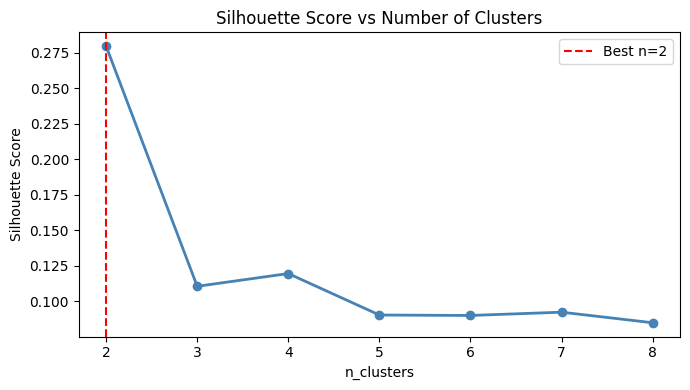

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(list(silhouette_scores.keys()),
         list(silhouette_scores.values()),
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_n, color='red', linestyle='--', label=f'Best n={best_n}')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('n_clusters')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
Z_final = linkage(X_scaled, method='ward')
df['cluster'] = fcluster(Z_final, t=best_n, criterion='maxclust')

In [22]:
df.head()

,product_name,category,price,discount_pct,final_price,rating,num_reviews,delivery_days,is_prime,was_returned,wishlist_count,cart_add_count,cluster
0,43,2,2060.34,20,1648.27,4.9,2201,2,0,0,377,419,2
1,20,2,3113.69,30,2179.58,3.3,484,1,0,0,111,119,2
2,39,3,9356.27,15,7952.83,4.8,3025,7,1,0,229,2413,2
3,10,6,14278.22,10,12850.40,3.5,970,7,1,1,142,159,2
4,8,1,682.71,5,648.57,4.1,280,1,1,0,183,176,2


In [23]:
df.cluster.value_counts()

cluster
2    1812
1     188
Name: count, dtype: int64

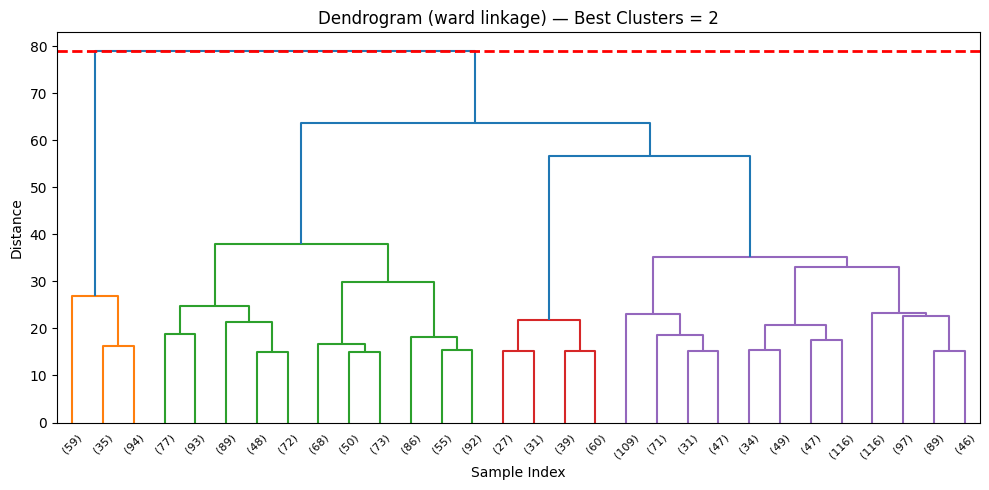

In [24]:
# Distance threshold for best_n clusters
cut_distance = Z_final[-(best_n - 1), 2]

plt.figure(figsize=(10, 5))

# Plot dendrogram
dendrogram(Z_final, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=8)

# Draw horizontal cut line
plt.axhline(y=cut_distance, color='red', linestyle='--', linewidth=2)

# Title and labels
plt.title(f'Dendrogram (ward linkage) — Best Clusters = {best_n}')
plt.xlabel('Sample Index')
plt.ylabel('Distance')

plt.tight_layout()
plt.show()

In [25]:
cut_distance

np.float64(78.97897429253415)

In [26]:
df.to_csv('amazon_clustered_final.csv', index=False)